In [34]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

In [35]:
input_dataset = Path('data/all_data_agg.csv')

In [56]:
lf = pl.scan_csv(input_dataset, schema_overrides={'run_id': pl.String})

print(lf.head(5).collect().to_dicts())

[{'run_id': '14870462622654356270', 'timestamp': 1771273305.869798, 'nodes': '6N', 'bandwidth': '20 MHz', 'tdd': '2-2', 'rank': '2x2', 'network': 'wwan', 'distribution': 'iid', 'server_round': 2.0, 'train_loss': 2.1372713155066947, 'train_time': 13.966661261550115, 'eval_loss': 2.3027823911741203, 'eval_acc': 0.0988746446327852, 'eval_time': 1.3551944328623509, 'round': 2.0, 'segment': 0.0, 'pcmax': 24.0, 'puschSnr': 17.5, 'inSync': 1.0, 'dlBytes': 46113607.0, 'phr': 48.0, 'ulMcs': 0.0, 'dlQm': 6.0, 'ulBytes': 22233803.0, 'ulQm': 2.0, 'ulBler': 0.010642432973252484, 'sinr': 23.0, 'dlMcs': 14.5, 'pucchSnr': 19.0, 'rsrq': -11.0, 'rsrp': -69.0, 'rssi': 57.85, 'cqi': 15.0, 'dlBler': 0.0014650260515296494, 'ri': 2.0, 'avgLdpcIterations': 1.8, 'id': 12345678.0, 'ulCarrierFreq': 3309420000.0, 'pci': 0.0, 'dlCarrierFreq': 3309420000.0, 'frame': 650.0, 'slot': 16.0, 'uplink_latency': 9.816209157307943, 'downlink_latency': 1.639567534128825, 'start_time': 1771273258.06, 'exec_time': 9342.99, 'up

### Helper to filter out bad latency

In [46]:
def filter_p99(df: pl.DataFrame, col: str) -> pl.DataFrame:
    p99 = df[col].quantile(0.80)
    return df.filter(pl.col(col) <= p99)

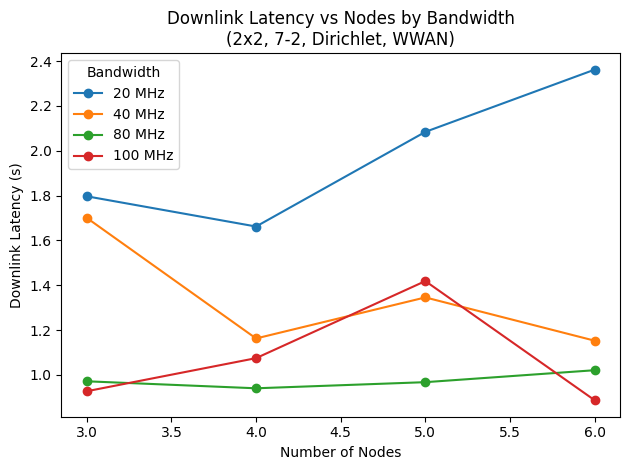

In [47]:
fig, ax = plt.subplots()

for bw in ["20 MHz", "40 MHz", "80 MHz", "100 MHz"]:
    filtered = (
        lf.filter(
            (pl.col("rank") == "2x2") &
            (pl.col("tdd") == "7-2") &
            (pl.col("distribution") == "dirichlet") &
            (pl.col("network") == "wwan") &
            (pl.col("bandwidth") == bw)
        )
        .select(["nodes", "downlink_latency"])
        .with_columns(pl.col("nodes").str.extract(r"(\d+)").cast(pl.Int32).alias("n_nodes"))
        .collect()
    )

    p99 = filtered["downlink_latency"].quantile(0.99)

    agg = (
        filtered
        .filter((pl.col("downlink_latency") <= p99) & (pl.col("n_nodes") > 1))
        .group_by("n_nodes")
        .agg(pl.col("downlink_latency").median().alias("median"))
        .sort("n_nodes")
    )

    if agg.is_empty():
        print(f"No data for {bw}, skipping")
        continue

    ax.plot(agg["n_nodes"], agg["median"], marker="o", label=bw)

ax.set_xlabel("Number of Nodes")
ax.set_ylabel("Downlink Latency (s)")
ax.set_title("Downlink Latency vs Nodes by Bandwidth\n(2x2, 7-2, Dirichlet, WWAN)")
ax.legend(title="Bandwidth")
plt.tight_layout()
plt.show()

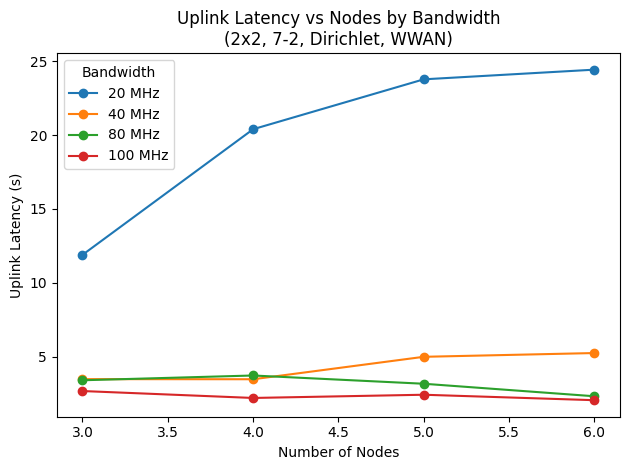

In [48]:
fig, ax = plt.subplots()

for bw in ["20 MHz", "40 MHz", "80 MHz", "100 MHz"]:
    filtered = (
        lf.filter(
            (pl.col("rank") == "2x2") &
            (pl.col("tdd") == "7-2") &
            (pl.col("distribution") == "dirichlet") &
            (pl.col("network") == "wwan") &
            (pl.col("bandwidth") == bw)
        )
        .select(["nodes", "uplink_latency"])
        .with_columns(pl.col("nodes").str.extract(r"(\d+)").cast(pl.Int32).alias("n_nodes"))
        .collect()
    )

    p99 = filtered["uplink_latency"].quantile(0.99)

    agg = (
        filtered
        .filter((pl.col("uplink_latency") <= p99) & (pl.col("n_nodes") > 1))
        .group_by("n_nodes")
        .agg(pl.col("uplink_latency").median().alias("median"))
        .sort("n_nodes")
    )

    if agg.is_empty():
        print(f"No data for {bw}, skipping")
        continue

    ax.plot(agg["n_nodes"], agg["median"], marker="o", label=bw)

ax.set_xlabel("Number of Nodes")
ax.set_ylabel("Uplink Latency (s)")
ax.set_title("Uplink Latency vs Nodes by Bandwidth\n(2x2, 7-2, Dirichlet, WWAN)")
ax.legend(title="Bandwidth")
plt.tight_layout()
plt.show()

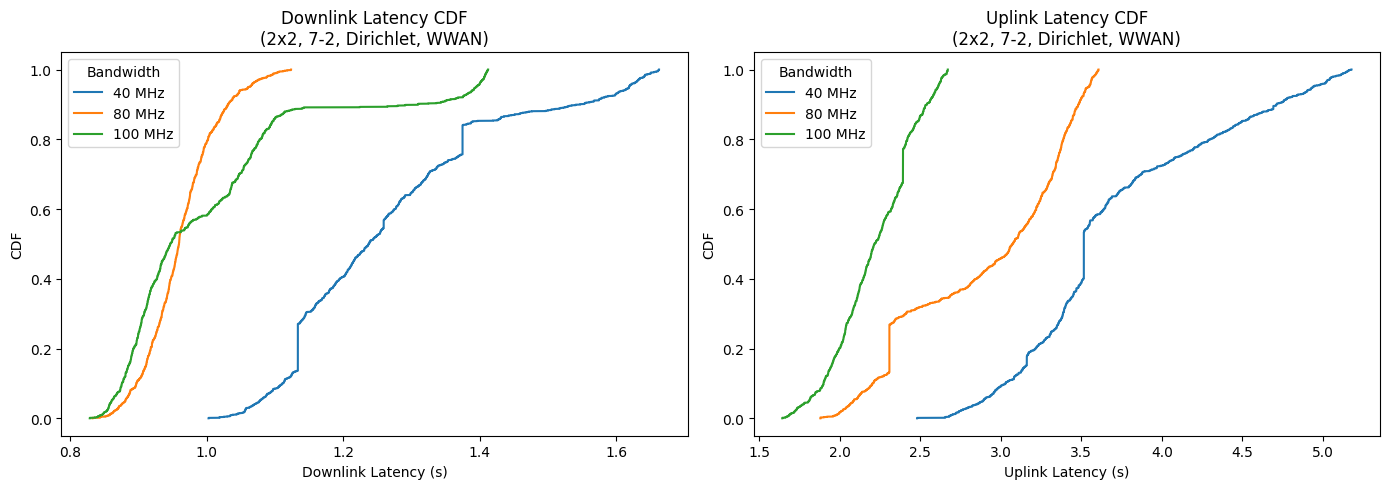

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for bw in ["40 MHz", "80 MHz", "100 MHz"]:
    filtered = (
        lf.filter(
            (pl.col("rank") == "2x2") &
            (pl.col("tdd") == "7-2") &
            (pl.col("distribution") == "dirichlet") &
            (pl.col("network") == "wwan") &
            (pl.col("bandwidth") == bw)
        )
        .select(["nodes", "downlink_latency", "uplink_latency"])
        .with_columns(pl.col("nodes").str.extract(r"(\d+)").cast(pl.Int32).alias("n_nodes"))
        .filter(pl.col("n_nodes") > 1)
        .collect()
    )

    if filtered.is_empty():
        print(f"No data for {bw}, skipping")
        continue

    for ax, col in zip(axes, ["downlink_latency", "uplink_latency"]):
        vals = filter_p99(filtered, col)[col].sort()
        cdf = np.arange(1, len(vals) + 1) / len(vals)
        ax.plot(vals, cdf, label=bw)

axes[0].set_xlabel("Downlink Latency (s)")
axes[0].set_ylabel("CDF")
axes[0].set_title("Downlink Latency CDF\n(2x2, 7-2, Dirichlet, WWAN)")
axes[0].legend(title="Bandwidth")

axes[1].set_xlabel("Uplink Latency (s)")
axes[1].set_ylabel("CDF")
axes[1].set_title("Uplink Latency CDF\n(2x2, 7-2, Dirichlet, WWAN)")
axes[1].legend(title="Bandwidth")

plt.tight_layout()
plt.show()

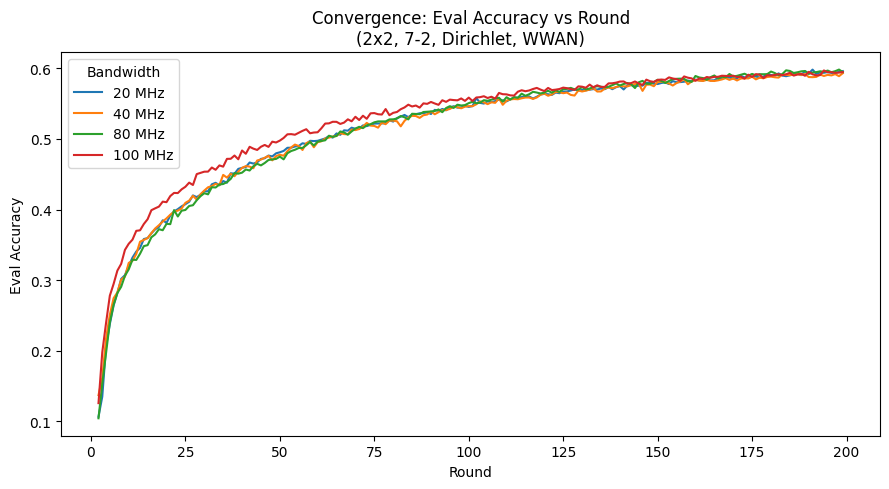

In [60]:
fig, ax = plt.subplots(figsize=(9, 5))

for bw in ["20 MHz", "40 MHz", "80 MHz", "100 MHz"]:
    filtered = (
        lf.filter(
            (pl.col("rank") == "2x2") &
            (pl.col("tdd") == "7-2") &
            (pl.col("distribution") == "dirichlet") &
            (pl.col("network") == "wwan") &
            (pl.col("bandwidth") == bw)
        )
        .select(["run_id", "round", "eval_acc"])
        .unique(subset=["run_id", "round"])
        .group_by("round")
        .agg(pl.col("eval_acc").mean().alias("mean_acc"))
        .sort("round")
        .collect()
    )

    if filtered.is_empty():
        print(f"No data for {bw}, skipping")
        continue

    ax.plot(filtered["round"], filtered["mean_acc"], label=bw)

ax.set_xlabel("Round")
ax.set_ylabel("Eval Accuracy")
ax.set_title("Convergence: Eval Accuracy vs Round\n(2x2, 7-2, Dirichlet, WWAN)")
ax.legend(title="Bandwidth")
plt.tight_layout()
plt.show()

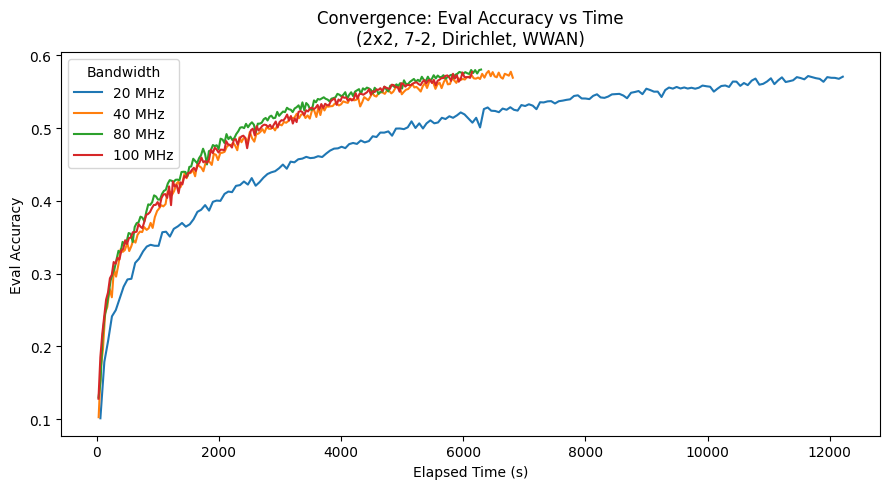

In [65]:
fig, ax = plt.subplots(figsize=(9, 5))

for bw in ["20 MHz", "40 MHz", "80 MHz", "100 MHz"]:
    filtered = (
        lf.filter(
            (pl.col("rank") == "2x2") &
            (pl.col("tdd") == "7-2") &
            (pl.col("distribution") == "dirichlet") &
            (pl.col("network") == "wwan") &
            (pl.col('nodes') == '6N') &
            (pl.col("bandwidth") == bw)
        )
        .select(["run_id", "round", "timestamp", "eval_acc"])
        .unique(subset=["run_id", "round"])
        .sort(["run_id", "round"])
        .with_columns(
            pl.col("timestamp").diff().over("run_id").alias("round_time")
        )
        .collect()
    )

    if filtered.is_empty():
        print(f"No data for {bw}, skipping")
        continue

    # replace round_time > 200 with median
    median_rt = filtered["round_time"].median()
    filtered = filtered.with_columns(
        pl.when(pl.col("round_time") > 200)
        .then(median_rt)
        .otherwise(pl.col("round_time"))
        .alias("round_time")
    )

    # elapsed = cumsum of cleaned round_time
    filtered = filtered.with_columns(
        pl.col("round_time").cum_sum().over("run_id").alias("elapsed")
    )

    agg = (
        filtered
        .group_by("elapsed")
        .agg(pl.col("eval_acc").mean().alias("mean_acc"))
        .sort("elapsed")
    )

    ax.plot(agg["elapsed"], agg["mean_acc"], label=bw)

ax.set_xlabel("Elapsed Time (s)")
ax.set_ylabel("Eval Accuracy")
ax.set_title("Convergence: Eval Accuracy vs Time\n(2x2, 7-2, Dirichlet, WWAN)")
ax.legend(title="Bandwidth")
plt.tight_layout()
plt.show()

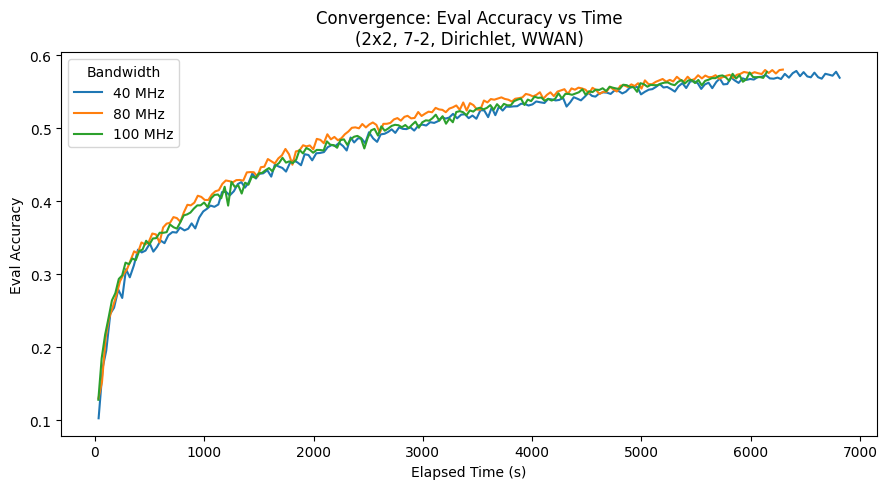

In [66]:
fig, ax = plt.subplots(figsize=(9, 5))

for bw in ["40 MHz", "80 MHz", "100 MHz"]:
    filtered = (
        lf.filter(
            (pl.col("rank") == "2x2") &
            (pl.col("tdd") == "7-2") &
            (pl.col("distribution") == "dirichlet") &
            (pl.col("network") == "wwan") &
            (pl.col('nodes') == '6N') &
            (pl.col("bandwidth") == bw)
        )
        .select(["run_id", "round", "timestamp", "eval_acc"])
        .unique(subset=["run_id", "round"])
        .sort(["run_id", "round"])
        .with_columns(
            pl.col("timestamp").diff().over("run_id").alias("round_time")
        )
        .collect()
    )

    if filtered.is_empty():
        print(f"No data for {bw}, skipping")
        continue

    # replace round_time > 200 with median
    median_rt = filtered["round_time"].median()
    filtered = filtered.with_columns(
        pl.when(pl.col("round_time") > 200)
        .then(median_rt)
        .otherwise(pl.col("round_time"))
        .alias("round_time")
    )

    # elapsed = cumsum of cleaned round_time
    filtered = filtered.with_columns(
        pl.col("round_time").cum_sum().over("run_id").alias("elapsed")
    )

    agg = (
        filtered
        .group_by("elapsed")
        .agg(pl.col("eval_acc").mean().alias("mean_acc"))
        .sort("elapsed")
    )

    ax.plot(agg["elapsed"], agg["mean_acc"], label=bw)

ax.set_xlabel("Elapsed Time (s)")
ax.set_ylabel("Eval Accuracy")
ax.set_title("Convergence: Eval Accuracy vs Time\n(2x2, 7-2, Dirichlet, WWAN)")
ax.legend(title="Bandwidth")
plt.tight_layout()
plt.show()

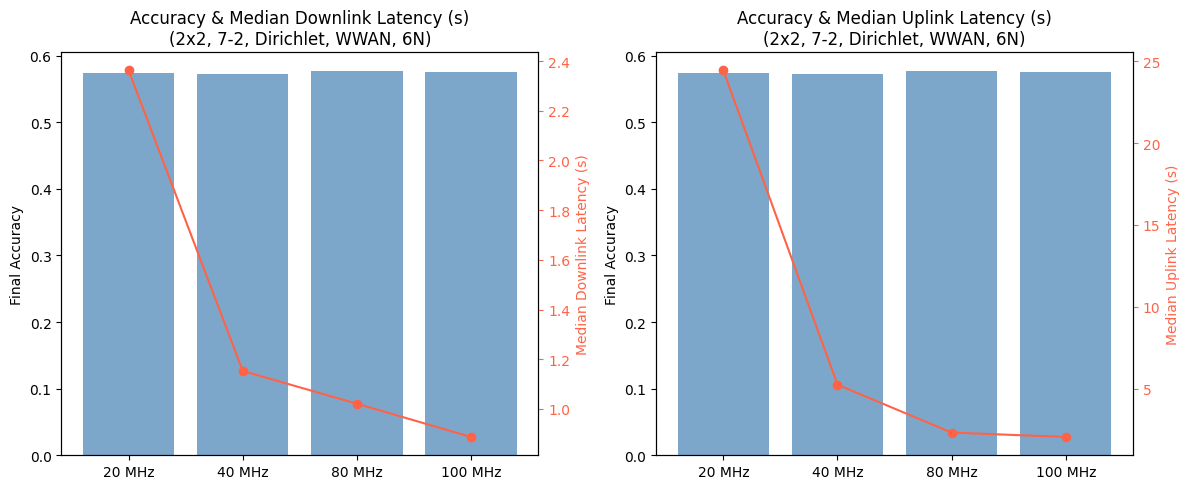

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bws = ["20 MHz", "40 MHz", "80 MHz", "100 MHz"]

for ax, col, label in zip(
    axes,
    ["median_downlink", "median_uplink"],
    ["Median Downlink Latency (s)", "Median Uplink Latency (s)"]
):
    latencies = [joined.filter(pl.col("bandwidth") == bw)[col].item() for bw in bws]
    accuracies = [joined.filter(pl.col("bandwidth") == bw)["accuracy"].item() for bw in bws]

    x = np.arange(len(bws))
    ax2 = ax.twinx()

    ax.bar(x, accuracies, color="steelblue", alpha=0.7, label="Accuracy")
    ax2.plot(x, latencies, color="tomato", marker="o", label=label)

    ax.set_xticks(x)
    ax.set_xticklabels(bws)
    ax.set_ylabel("Final Accuracy")
    ax2.set_ylabel(label, color="tomato")
    ax2.tick_params(axis="y", colors="tomato")
    ax.set_title(f"Accuracy & {label}\n(2x2, 7-2, Dirichlet, WWAN, 6N)")

plt.tight_layout()
plt.show()